In [16]:
import pandas as pd

from sembench.src.closed_model_stats import MMQA_STATS, MOVIE_STATS, ECOMM_STATS, WILDLIFE_STATS, CARS_STATS, QUERY_TO_MODALITIES

In [17]:
all_model_avgs = []
CLOSED_COLNAME = "Avg. SemBench System with gemini-2.5-flash"
OPEN_COLNAME = "BlendSQL w/ local gemma-4-E4B-it-fp8"
hourly_rate = 0.18
for task, stat in [('mmqa', MMQA_STATS), ('movie', MOVIE_STATS), ('ecomm', ECOMM_STATS), ('wildlife', WILDLIFE_STATS), ('cars', CARS_STATS)]:
    bl_agg = (
            pd.DataFrame(stat).groupby('query')
            .agg(bl_latency=('latency', 'mean'),
                 bl_quality=('quality', 'mean'),
                 bl_cost=('cost', 'mean'))
            .reset_index()
            .rename(columns={'query': 'query_name'})
        )
    bl_agg['bl_cost_scaled'] = bl_agg['bl_cost'] * 5
    all_model_avgs.append(
        {
            "task": task,
            "latency": bl_agg['bl_latency'].mean(),
            "quality": bl_agg['bl_quality'].mean(),
            "cost": bl_agg['bl_cost_scaled'].mean(),
            "model": CLOSED_COLNAME,
        }
    )

    df_bs = pd.read_csv(f"../results/blendsql_comparison_to_closed/{task}/gemma_e4b/all_results_with_runs.csv")
    df_bs['cost'] = df_bs['latency'] * hourly_rate / 3600.0
    bs_agg = (
        df_bs.groupby('query_name')
        .agg(bs_latency=('latency', 'mean'),
             bs_quality=('quality', 'mean'),
             bs_cost=('cost', 'mean'))
        .reset_index()
    )
    bs_agg['bs_cost_scaled'] = bs_agg['bs_cost'] * 5
    all_model_avgs.append(
        {
            "task": task,
            "latency": bs_agg['bs_latency'].mean(),
            "quality": bs_agg['bs_quality'].mean(),
            "cost": bs_agg['bs_cost_scaled'].mean(),
            "model": OPEN_COLNAME,
        }
    )

df = pd.DataFrame(all_model_avgs)

In [18]:
query_to_modalities = []
for scenario, queries in QUERY_TO_MODALITIES.items():
    for query_name, modalities in queries.items():
        for modality in modalities:
            query_to_modalities.append({
                'query_name': query_name,
                'modality': modality,
                'scenario': scenario
            })
query_to_modalities = pd.DataFrame(query_to_modalities)
query_to_modalities.head()

,query_name,modality,scenario
0,Q1,text,mmqa
1,Q2a,text,mmqa
2,Q2a,image,mmqa
3,Q2b,text,mmqa
4,Q2b,image,mmqa


In [21]:
per_query_rows = []
for task, stat in [('mmqa', MMQA_STATS), ('movie', MOVIE_STATS), ('ecomm', ECOMM_STATS), ('wildlife', WILDLIFE_STATS), ('cars', CARS_STATS)]:
    # Closed: avg quality across all systems per query
    closed_agg = (
        pd.DataFrame(stat)
        .groupby('query', as_index=False)
        .agg(quality=('quality', 'mean'))
        .rename(columns={'query': 'query_name'})
    )
    closed_agg['scenario'] = task
    closed_agg['model'] = CLOSED_COLNAME

    # Open: blendsql per query
    df_bs = pd.read_csv(f"../results/blendsql_comparison_to_closed/{task}/gemma_e4b/all_results_with_runs.csv")
    open_agg = (
        df_bs.groupby('query_name', as_index=False)
        .agg(quality=('quality', 'mean'))
    )
    open_agg['scenario'] = task
    open_agg['model'] = OPEN_COLNAME

    per_query_rows.append(closed_agg)
    per_query_rows.append(open_agg)

per_query_df = pd.DataFrame(pd.concat(per_query_rows, ignore_index=True))

# Pivot to get one row per (scenario, query_name) with both model qualities
pivot = per_query_df.pivot_table(index=['scenario', 'query_name'], columns='model', values='quality').reset_index()
pivot.columns.name = None
pivot['quality_diff'] = pivot[OPEN_COLNAME] - pivot[CLOSED_COLNAME]

# Join with modalities (one row per modality type each query has)
merged = pivot.merge(query_to_modalities, on=['scenario', 'query_name'], how='inner')
merged.head()

,scenario,query_name,Avg. SemBench System with gemini-2.5-flash,BlendSQL w/ local gemma-4-E4B-it-fp8,quality_diff,modality
0,cars,Q1,0.777500,0.634246,-0.143254,text
1,cars,Q2,0.056667,0.000000,-0.056667,audio
2,cars,Q3,0.940000,0.940000,0.000000,image
3,cars,Q4,0.992500,0.990434,-0.002066,text
4,cars,Q5,1.000000,0.000000,-1.000000,image


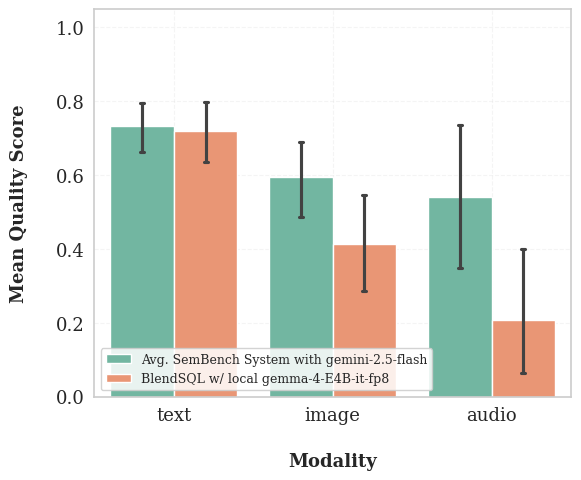

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

MODALITY_ORDER = ['text', 'image', 'audio']

plot_df = merged.melt(
    id_vars=['scenario', 'query_name', 'modality'],
    value_vars=[CLOSED_COLNAME, OPEN_COLNAME],
    var_name='model',
    value_name='quality'
)

plt.rcParams.update({
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "font.size": 13,
    "axes.linewidth": 1.2,
})

palette = sns.color_palette("Set2", 2)

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data=plot_df,
    x='modality', y='quality',
    hue='model',
    order=MODALITY_ORDER,
    palette=palette,
    capsize=0.05,
    ax=ax,
)

ax.set_xlabel('Modality', fontsize=13, fontweight='bold', labelpad=20)
ax.set_ylabel('Mean Quality Score', fontsize=13, fontweight='bold', labelpad=20)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_axisbelow(True)
ax.legend(title='', fontsize=9, frameon=True, framealpha=0.85, edgecolor='#ccc', loc='lower left')

fig.tight_layout()
fig.savefig('../img/modality_quality.pdf', bbox_inches='tight')
plt.show()

In [24]:
diff_by_modality = (
    merged.groupby('modality')['quality_diff']
    .agg(mean_diff='mean', count='count')
    .reindex(['text', 'image', 'audio'])
)
for modality, row in diff_by_modality.iterrows():
    direction = "open BETTER" if row['mean_diff'] > 0 else "open WORSE"
    print(f"{modality:6s}: {row['mean_diff']:+.4f}  ({direction}, n={int(row['count'])} queries)")

text  : -0.0233  (open WORSE, n=33 queries)
image : -0.1813  (open WORSE, n=25 queries)
audio : -0.3321  (open WORSE, n=10 queries)
